# **Nestrov Accelerated Gradient (NAG)**
After we have mentioned **The pitfall of Momentum** before. Now it's the time to overcome this pitfall and come up with  a solution.
so we have came up with an intermediate step to make the velocity lesser

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
def f(x):
    return x**2 + 4*x + 4

In [4]:
def df(x):
    return 2*x + 4

# NAG Implementation

In [4]:
def nag_gradient_descent(starting_point,
                         learning_rate,
                         iterations,
                         gamma=0.9):

    theta = starting_point
    v = 0
    history = [theta]

    for i in range(iterations):
        # 1️ --> Look-ahead step
        theta_temp = theta - gamma * v
        # 2 --> Gradient at look-ahead
        grad = df(theta_temp)
        # 3 --> Update velocity
        v = gamma * v + learning_rate * grad
        # 4 --> Update parameter
        theta = theta - v
        history.append(theta)
        print(f"Iter {i+1}: θ={theta:.4f}, f(θ)={f(theta):.4f}, v={v:.4f}")

    return theta, history

In [5]:
def visualize(history, learning_rate, optimizer_name="Optimizer"):
    x_vals = np.linspace(-10, 2, 200)
    y_vals = f(x_vals)

    plt.figure()

    for i, x_i in enumerate(history):
        plt.clf()

        # function curve
        plt.plot(x_vals, y_vals, label="f(x)=x²+4x+4")

        # trajectory
        plt.scatter(history[:i+1],
                    [f(x) for x in history[:i+1]])

        # current point
        plt.scatter(x_i, f(x_i),
                    s=120,
                    label=f"Iteration {i}")

        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.title(f"{optimizer_name} | LR={learning_rate}, Iter={i}")
        plt.legend()
        plt.pause(0.4)

    plt.show()

# **Adaptive Gradient Agagrad (AGA)**

In [9]:
'''
- We use this optimizer to deal with sprase features 
which is a feature vector full of zero values that we cannot 
even remove it or get rid of it
- We always will face these data in most of the real datasets we see
- So we will have different learning rates for each feature to make the update component to be realistic
- all of that will lead us to the new concept of effective learning rate
'''
# the equations
# [theta_0 , theta_1]_t+1 = [theta_0 , theta_1]_t - [lr/v_t , lr/v_t] * [gradient_of_theta_0 , gradient_of_theta_1]
# v_t = v_t-1 + (gradient_of_theta)**2

def adaptive_gradient_aga(starting_point , learning_rate , iter , epsilon = 1e-7):

    x = starting_point
    
    v = 0   # accumulator
    x_history = []
    f_history = []
    
    for i in range(iter):

        grad = df(x)

        # accumulate squared gradients
        v = v + grad**2

        # effective learning rate
        effective_lr = learning_rate / (np.sqrt(v) + epsilon)

        # update step
        x = x - effective_lr * grad

        x_history.append(x)
        f_history.append(f(x))
    # we could ignore returing the history but it's for elaborating pruposes
    return x , x_history , f_history

Minimum found at: -1.9999999999999998


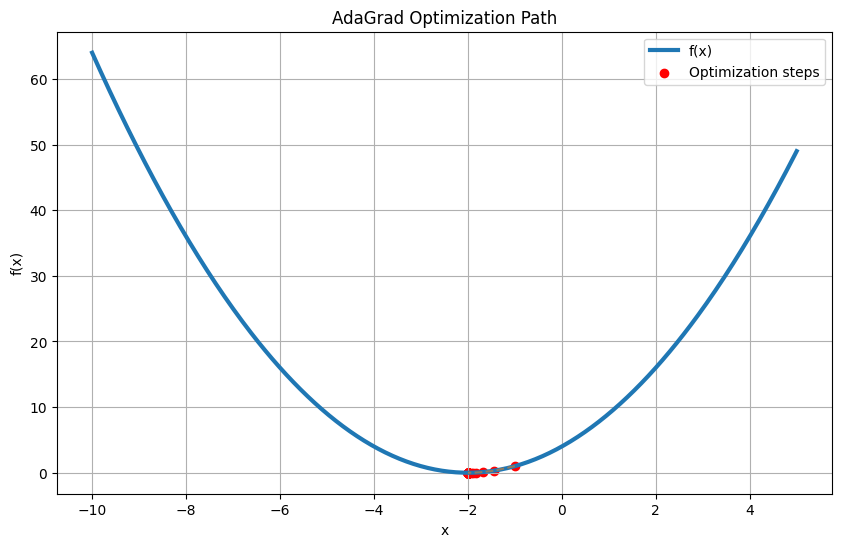

In [10]:
def visualize_optimization(x_history):

    x_vals = np.linspace(-10 , 5 , 400)
    y_vals = f(x_vals)

    plt.figure(figsize=(10,6))

    plt.plot(x_vals , y_vals , label="f(x)", linewidth=3)

    plt.scatter(x_history ,
                [f(x) for x in x_history],
                color='red',
                label="Optimization steps")

    plt.plot(x_history ,
             [f(x) for x in x_history],
             linestyle='--',
             alpha=0.5)

    plt.title("AdaGrad Optimization Path")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()

    plt.grid()
    plt.show()


# run
minimum , x_hist , f_hist = adaptive_gradient_aga(
    starting_point =0 ,
    learning_rate = 1,
    iter = 100
)

print("Minimum found at:", minimum)

visualize_optimization(x_hist)

# **RMS PROP**

In [11]:
'''
To avoid the aggressive accumlation of the gradients which could hinderr the updating
we have came up with a new equation for the v_t
v_t = beta*v_t-1 + (1-beta)(gradient_of_theta)
this parameter found a relation between the history and current gradient
this phenomena called exponential weighted moving average (EWMA)
'''

def rms_prop(starting_point , learning_rate , iter ,beta = 0.9 , epsilon = 1e-7):

    x = starting_point
    
    v = 0   # accumulator
    x_history = []
    f_history = []
    
    for i in range(iter):

        grad = df(x)

        # accumulate squared gradients
        v = beta*v + (1-beta)*grad**2

        # effective learning rate
        effective_lr = learning_rate / (np.sqrt(v) + epsilon)

        # update step
        x = x - effective_lr * grad

        x_history.append(x)
        f_history.append(f(x))
    # we could ignore returing the history but it's for elaborating pruposes
    return x , x_history , f_history

In [12]:
def visualize_optimization(x_history , optimizer_name="Optimizer"):

    x_vals = np.linspace(-10 , 5 , 400)
    y_vals = f(x_vals)

    plt.figure(figsize=(10,6))

    # Function curve
    plt.plot(x_vals , y_vals ,
             color='navy',
             linewidth=3,
             label="f(x)")

    # Optimization path
    y_history = [f(x) for x in x_history]

    plt.scatter(x_history ,
                y_history,
                color='red',
                s=60,
                zorder=3,
                label="Steps")

    plt.plot(x_history ,
             y_history,
             color='red',
             linestyle='--',
             alpha=0.6)

    # Start point
    plt.scatter(x_history[0],
                y_history[0],
                color='orange',
                s=120,
                label="Start",
                zorder=4)

    # True minimum
    plt.scatter(-2 , 0 ,
                color='green',
                s=150,
                marker='*',
                label="True minimum",
                zorder=5)

    # Final point
    plt.scatter(x_history[-1],
                y_history[-1],
                color='black',
                s=120,
                label="Final",
                zorder=4)

    plt.title(f"{optimizer_name} Optimization Path",
              fontsize=14,
              fontweight='bold')

    plt.xlabel("x")
    plt.ylabel("f(x)")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

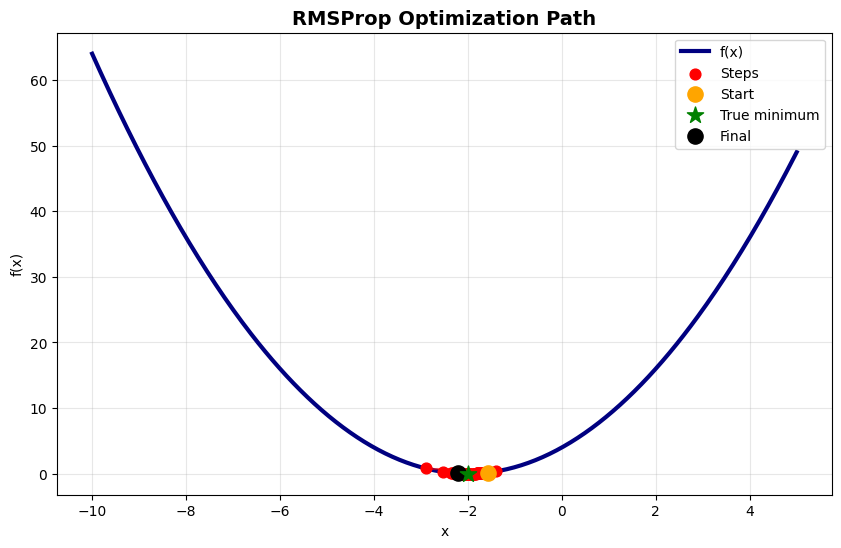

In [13]:
minimum , x_hist , f_hist = rms_prop(
    starting_point = 0,
    learning_rate = 0.5,
    iter = 100,
    beta = 0.9
)

visualize_optimization(x_hist , "RMSProp")

# **ADAM**

In [15]:
'''As the previous optimizers only care about the sparse feature not vanishing gradiant
So we need to find a solution that solves both
which we mix both of momentum method and rmsprop

m_t = beta_1 * m_t-1 + (1-beta_1) (gradient_of_theta)
v_t = beta_2 * v_t-1 + (1-beta_2) (gradient_of_theta)**2
theta_t+1 = theta_1 - (alpha / (sqrt(v_t) + epsilon) ) * m_t 
'''
def Adam(starting_point, learning_rate, iter,
         beta_1=0.9, beta_2=0.999, epsilon=1e-8):

    x = starting_point

    m = 0      # first moment
    v = 0      # second moment

    x_history = []
    f_history = []

    for t in range(1, iter+1):

        grad = df(x)

        # momentum
        m = beta_1*m + (1-beta_1)*grad

        # rmsprop
        v = beta_2*v + (1-beta_2)*grad**2

        # bias correction
        m_hat = m / (1-beta_1**t)
        v_hat = v / (1-beta_2**t)

        # update
        x = x - learning_rate * m_hat / (np.sqrt(v_hat)+epsilon)

        x_history.append(x)
        f_history.append(f(x))

    return x, x_history, f_history

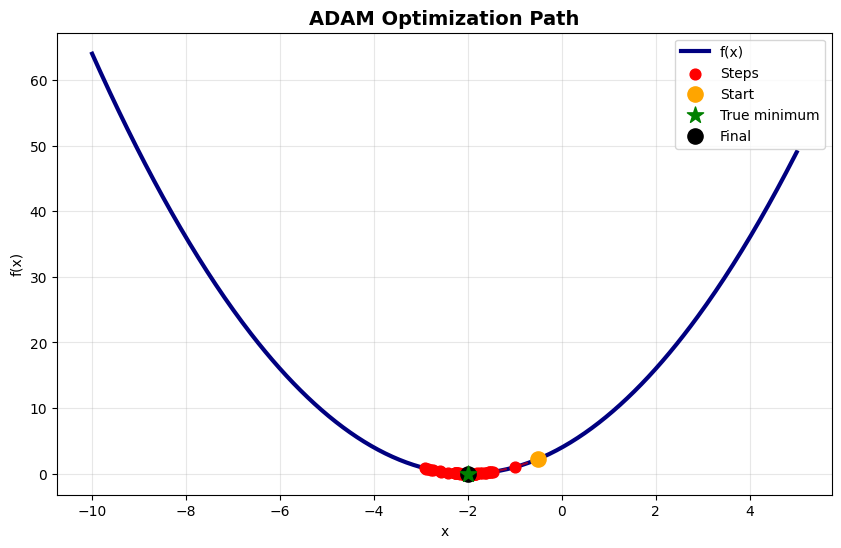

In [16]:
minimum , x_hist , f_hist = Adam(
    starting_point = 0,
    learning_rate = 0.5,
    iter = 100
)

visualize_optimization(x_hist , "ADAM")